<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab1/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_1_Linear_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>The Linear Regression Algorithm</b></h1> <p align="justify">In this exercise you will study the <i>linear regression</i> algorithm by developing your own Python program that implements all the necessary steps, without using any Python library that implements the <i>linear regression</i> model, such as <i>Scikit-Learn</i>.</p> <p align="justify">Initially, two training data files are provided: (a) <i><a href="https://github.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/blob/main/lab1/data1a.csv">data1a.csv</a></i> and (b) <i><a href="https://github.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/blob/main/lab1/data1b.csv">data1b.csv</a></i>. Each row of the file <i>data1a.csv</i> includes information related to viewing a video on <i>YouTube</i>, such as <i>title</i>, <i>number of views</i>, <i>likes</i>, <i>dislikes</i>, etc. Overall, the file <i>data1a.csv</i> contains 11 columns. More information about the file <i>data1a.csv</i> can be found <a href="https://www.kaggle.com/akanshasingh/us-videos-csv">here</a>. The file <i>data1b.csv</i> contains 2 columns with headers x and y respectively. These values do not have any physical meaning. More information can be found <a href="https://www.kaggle.com/testpython/linear-regression-with-single-variable">here</a>.</p> <p align="justify">The purpose of the exercise is to develop a simple <i>linear regression</i> model, which will be able to estimate (a) for the case of the file <i>data1a.csv</i> the number of <i>views</i> (dependent variable) of a video based on the number of <i>likes</i> (independent variable) it has received, and (b) for the case of the file <i>data1b.csv</i> the value of the variable y based on the values of the variable x. Develop a single program that does the following:</p> <ul> <li>It will load the data from the .csv files and isolate the columns that matter, i.e., in the case of the file data1a.csv the columns with headers views and likes, and in the case of the file data1b.csv the columns with headers y and x.</li> <li>It will compute the correlation between the independent and dependent variable of the provided data. This step is necessary to determine the degree of linear dependence between the two variables. What correlation results in the two cases? Is the linear dependence between the two variables satisfactory? For this question, study the source <a href="https://en.wikipedia.org/wiki/Correlation_and_dependence">here</a>.</li> <li>It will plot the points that arise as pairs of the independent and dependent variable isolated in the first question. What do you observe in relation to the conclusions you reached in the second question?</li> <li>It will normalize the provided data using the min-max normalization method. More information about this method can be found <a href="https://en.wikipedia.org/wiki/Feature_scaling">here</a>.</li> <li>It will randomly split the provided data into two subsets: (a) the training set, which includes the data that will be used to train the model, and (b) the test set, which includes the data that will be used to compute the model’s accuracy. The user will define the percentage of each file relative to the original.</li> <li>It will compute the parameters of the linear regression model using the Stochastic Gradient Descent (SGD) method. For this purpose, the user must define the learning rate and the total number of training epochs. Assume that the initial values of the parameters are zero.</li> <li>It will compute the mean squared error of the predictions on the test set. More information can be found <a href="https://en.wikipedia.org/wiki/Mean_squared_error">here</a>.</li> </ul> <p align="justify">Assume that the test set is 20% of the original dataset. What do you observe happens in the case where the data are not normalized? Experiment with the values of the learning rate and the number of epochs to see how the mean squared error changes.<p>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
data1a = pd.read_csv('/content/drive/MyDrive/NTUA FINANCIAL ENGINEERING MASTER/2nd Semester/Stochastic Processes & Optimization in Machine Learning/Lab1/data1a.csv')
print(data1a)

         video_id                                              title  \
0     XpVt6Z1Gjjo  1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...   
1     K4wEI5zhHB0            iPhone X — Introducing iPhone X — Apple   
2     cLdxuaxaQwc                                        My Response   
3     WYYvHb03Eog                          Apple iPhone X first look   
4     sjlHnJvXdQs                                  iPhone X (parody)   
...           ...                                                ...   
7991  xlu6i6lT_vk                     How Do MASSIVE Sinkholes Form?   
7992  qRoVlH1OcI4  Trump slams Clinton for defending NFL anthem p...   
7993  EoejGgUNmVU  LP - Lost On You (A Night at The McKittrick Ho...   
7994  MT1CMTI0EVw  Tré Melvin @ #YouTubeBlack FanFest Washington ...   
7995  AFxLA3RGjnc  First cosmic event seen in gravitational waves...   

                    channel_title  category_id  \
0                Logan Paul Vlogs           24   
1                           Apple  

In [39]:
print(data1a.columns)

Index(['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views',
       'likes', 'dislikes', 'comment_total', 'thumbnail_link', 'date'],
      dtype='object')


In [40]:
data1a_isolated = data1a[['views','likes']]
print(data1a_isolated.head())

     views   likes
0  4394029  320053
1  7860119  185853
2  5845909  576597
3  2642103   24975
4  1168130   96666


In [41]:
# Independent variable (x) = likes
# Dependent variable (y) = views

x = data1a['likes'].tolist()
y = data1a['views'].tolist()

n = len(x)

# Means
mean_x = sum(x) / n
mean_y = sum(y) / n

# Numerator
numerator = 0
for i in range(n):
    numerator += (x[i] - mean_x) * (y[i] - mean_y)

# Denominator parts
sum_sq_x = 0
sum_sq_y = 0

for i in range(n):
    sum_sq_x += (x[i] - mean_x) ** 2
    sum_sq_y += (y[i] - mean_y) ** 2

denominator = (sum_sq_x * sum_sq_y) ** 0.5

# Correlation coefficient
r = numerator / denominator

print("Correlation coefficient =", r)

Correlation coefficient = 0.8328529740275511


For the views–likes dataset, the correlation is
r=0.8329, indicating a strong positive linear relationship.
This suggests that higher numbers of likes are associated with higher numbers of views, although some variability remains. A linear model could reasonably describe the relationship.

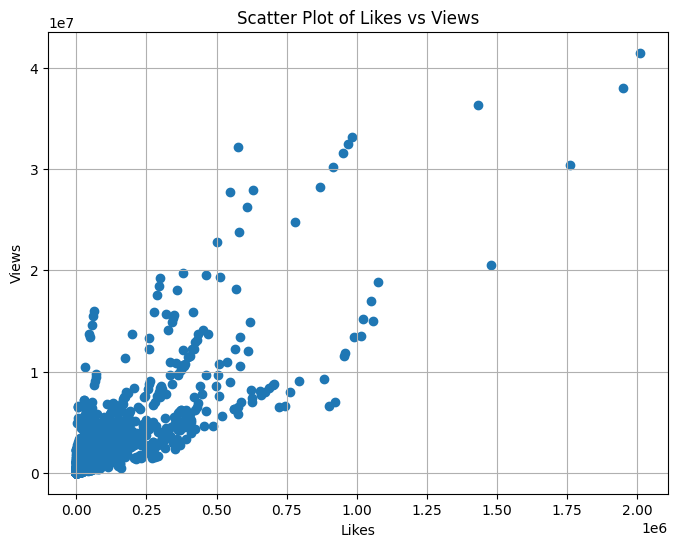

In [42]:
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Likes')
plt.ylabel('Views')
plt.title('Scatter Plot of Likes vs Views')
plt.grid(True)
plt.show()

For the views–likes dataset, the scatter plot shows a clear positive trend, but with greater dispersion of points around the linear direction. This indicates a strong but not perfect linear relationship, which is consistent with the Pearson correlation coefficient (r=0.8329) obtained in Question 2.

In [43]:
views = data1a['views'].tolist()
likes = data1a['likes'].tolist()

# min and max manually
min_views = min(views)
max_views = max(views)

min_likes = min(likes)
max_likes = max(likes)

# Normalized manually
views_normalized = []
for v in views:
    norm_v = (v - min_views) / (max_views - min_views)
    views_normalized.append(norm_v)

likes_normalized = []
for l in likes:
    norm_l = (l - min_likes) / (max_likes - min_likes)
    likes_normalized.append(norm_l)


# First 5 normalized pairs
for i in range(5):
    print("views:", views_normalized[i], "likes:", likes_normalized[i])

views: 0.10587850240111775 likes: 0.1592013593544658
views: 0.18939739096272948 likes: 0.09244734540874647
views: 0.1408629961461829 likes: 0.28681195364426176
views: 0.06366410163189647 likes: 0.012423111015606114
views: 0.028147255061315633 likes: 0.048083781759142366


In [44]:
import random

# Normalized data
x = likes_normalized
y = views_normalized

# User-defined percentages
train_percentage = 80
test_percentage = 20

if train_percentage + test_percentage != 100:
    print("Error: percentages must add up to 100.")
else:
    # Creates pairs so x and y stay matched
    data = []
    for i in range(len(x)):
        data.append([x[i], y[i]])

    # Shuffle randomly
    random.shuffle(data)

    # Split point
    train_size = int(len(data) * train_percentage / 100)

    # Creates subsets
    train_set = data[:train_size]
    test_set = data[train_size:]

    # Separates again into x and y
    x_train = []
    y_train = []
    for pair in train_set:
        x_train.append(pair[0])
        y_train.append(pair[1])

    x_test = []
    y_test = []
    for pair in test_set:
        x_test.append(pair[0])
        y_test.append(pair[1])

    # Prints sizes
    print("Total samples:", len(data))
    print("Training samples:", len(train_set))
    print("Test samples:", len(test_set))

    # Shows first 5 examples
    print("\nFirst 5 training samples:")
    for i in range(min(5, len(train_set))):
        print(train_set[i])

    print("\nFirst 5 test samples:")
    for i in range(min(5, len(test_set))):
        print(test_set[i])

Total samples: 7996
Training samples: 6396
Test samples: 1600

First 5 training samples:
[0.035823327692569414, 0.0912652691503405]
[0.02199848186847569, 0.013246050569976313]
[0.0577919642492959, 0.07603382904257551]
[0.0031561417174783097, 0.019163207766852545]
[0.10651841505477112, 0.07228680537992252]

First 5 test samples:
[0.3512315667893309, 0.21224774384376233]
[0.0007953775581162833, 0.0008200349141334386]
[0.04644079734734869, 0.09752630029701688]
[0.005871070242930889, 0.006978730368510659]
[1.4922655874601937e-06, 6.662542717380576e-05]


The dataset was randomly shuffled and then split into a training set and a test set according to the selected percentages. Each sample was kept as a pair [likes,views] so that the independent and dependent variable remained correctly matched.

The percentage of data assigned to each subset was defined by  assinging two new variables with: train_percentage = 80 and
test_percentage = 20, meaning that 80% of the observations were used for training and 20% for testing. After the split, the training set contained 6396 samples and the test set contained 1600 samples, preserving the original data distribution.

In [45]:
learning_rate = 0.01
epochs = 100

# Initial parameter values
w = 0
b = 0

# To store loss per epoch
loss_history = []

# SGD training
for epoch in range(epochs):
    total_loss = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        y_i = y_train[i]

        # Prediction
        y_pred = w * x_i + b

        # Error
        error = y_pred - y_i

        # Loss for this sample
        sample_loss = error ** 2
        total_loss += sample_loss

        # Gradients of squared error
        dw = 2 * error * x_i
        db = 2 * error

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

    # Mean loss of epoch
    mean_loss = total_loss / len(x_train)
    loss_history.append(mean_loss)

    print("Epoch:", epoch + 1, "Loss:", mean_loss, "w:", w, "b:", b)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Epoch: 1 Loss: 0.002237097072111853 w: 0.20931771372260033 b: 0.016204017672730334
Epoch: 2 Loss: 0.0016863589603929839 w: 0.37143273744439204 b: 0.013751789782959946
Epoch: 3 Loss: 0.001355361356654228 w: 0.4972270844031803 b: 0.011848965486322418
Epoch: 4 Loss: 0.0011555430332101828 w: 0.594838134653179 b: 0.010372454955234298
Epoch: 5 Loss: 0.0010348258628674926 w: 0.6705801481955648 b: 0.00922674573117897
Epoch: 6 Loss: 0.0009618269207686871 w: 0.7293527215954202 b: 0.008337724218329946
Epoch: 7 Loss: 0.0009176299306315696 w: 0.7749577329027572 b: 0.007647881426010672
Epoch: 8 Loss: 0.000890829457879312 w: 0.8103452773989412 b: 0.007112592829236605
Epoch: 9 Loss: 0.0008745459501913697 w: 0.8378045032508984 b: 0.006697231699097112
Epoch: 10 Loss: 0.0008646276730575324 w: 0.859111691842925 b: 0.006374929170198667
Epoch: 11 Loss: 0.0008585674637053096 w: 0.8756451618010249 b: 0.0061248361484962915
Epoch: 12 Loss: 0.0008548500217145661 w: 0.8884744296171387 b: 0.0059307746258702556
Epo

In [46]:
y_pred_test = []

for i in range(len(x_test)):
    prediction = w * x_test[i] + b
    y_pred_test.append(prediction)

# Mean Squared Error manually
mse = 0

for i in range(len(y_test)):
    mse += (y_test[i] - y_pred_test[i]) ** 2

mse = mse / len(y_test)

print("Mean Squared Error on test set =", mse)

Mean Squared Error on test set = 0.0007502712316950031


*Assume that the test set is 20% of the original dataset. What do you observe happens in the case where the data are not normalized?*

In [47]:
# Independent variable
x = data1a['likes'].tolist()

# Dependent variable
y = data1a['views'].tolist()

# User defines percentages
train_percentage = 80
test_percentage = 20

if train_percentage + test_percentage != 100:
    print("Error: percentages must add up to 100.")
else:
    # Creates pairs so x and y stay matched
    data = []
    for i in range(len(x)):
        data.append([x[i], y[i]])

    # Shuffles randomly
    random.shuffle(data)

    # Splits point
    train_size = int(len(data) * train_percentage / 100)

    # Creates subsets
    train_set = data[:train_size]
    test_set = data[train_size:]

    # Separates again into x and y
    x_train = []
    y_train = []
    for pair in train_set:
        x_train.append(pair[0])
        y_train.append(pair[1])

    x_test = []
    y_test = []
    for pair in test_set:
        x_test.append(pair[0])
        y_test.append(pair[1])

    # Prints sizes
    print("Total samples:", len(data))
    print("Training samples:", len(train_set))
    print("Test samples:", len(test_set))

    # Shows first 5 examples
    print("\nFirst 5 training samples:")
    for i in range(min(5, len(train_set))):
        print(train_set[i])

    print("\nFirst 5 test samples:")
    for i in range(min(5, len(test_set))):
        print(test_set[i])

Total samples: 7996
Training samples: 6396
Test samples: 1600

First 5 training samples:
[21950, 327341]
[1593, 22656]
[1032, 182568]
[10169, 186321]
[335, 107072]

First 5 test samples:
[20607, 528235]
[7892, 51357]
[126, 123334]
[52876, 643106]
[14969, 638777]


In [48]:
learning_rate = 1e-12
epochs = 20

# Initial parameter values
w = 0
b = 0

# To store loss per epoch
loss_history = []

# SGD training
for epoch in range(epochs):
    total_loss = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        y_i = y_train[i]

        # Prediction
        y_pred = w * x_i + b

        # Error
        error = y_pred - y_i

        # Loss for this sample
        sample_loss = error ** 2
        total_loss += sample_loss

        # Gradients of squared error
        dw = 2 * error * x_i
        db = 2 * error

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

    # Mean loss of epoch
    mean_loss = total_loss / len(x_train)
    loss_history.append(mean_loss)

    print("Epoch:", epoch + 1, "Loss:", mean_loss, "w:", w, "b:", b)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Epoch: 1 Loss: 2281872575319.263 w: 20.51663938086504 b: 0.002923650884219422
Epoch: 2 Loss: 2271856714130.595 w: 20.516639365672056 b: 0.005761251471728106
Epoch: 3 Loss: 2271856710036.3633 w: 20.516639350479068 b: 0.008598852028627734
Epoch: 4 Loss: 2271856705942.1143 w: 20.51663933528608 b: 0.011436452554918264
Epoch: 5 Loss: 2271856701847.879 w: 20.516639320093084 b: 0.014274053050599778
Epoch: 6 Loss: 2271856697753.64 w: 20.51663930490011 b: 0.017111653515672298
Epoch: 7 Loss: 2271856693659.404 w: 20.5166392897071 b: 0.01994925395013577
Epoch: 8 Loss: 2271856689565.1655 w: 20.51663927451413 b: 0.02278685435399021
Epoch: 9 Loss: 2271856685470.924 w: 20.516639259321135 b: 0.025624454727235724
Epoch: 10 Loss: 2271856681376.693 w: 20.51663924412814 b: 0.02846205506987209
Epoch: 11 Loss: 2271856677282.4526 w: 20.516639228935155 b: 0.0312996553818996
Epoch: 12 Loss: 2271856673188.2144 w: 20.51663921374216 b: 0.03413725566331806
Epoch: 13 Loss: 2271856669093.9766 w: 20.516639198549182 b:

In [49]:
mse_test = 0

for i in range(len(x_test)):
    y_pred = w * x_test[i] + b
    mse_test += (y_test[i] - y_pred) ** 2

mse_test = mse_test / len(x_test)

print("\nMean Squared Error on test set =", mse_test)


Mean Squared Error on test set = 1315263616588.2766


This experiment shows exactly why feature scaling is so important for SGD. Without normalization, the algorithm's gradients become massive and erratic. To stop the calculations from exploding and crashing the model, we had to shrink the learning rate to a microscopic 1e-12. Even with this tiny rate, the model learns too slowly and finishes with a huge Mean Squared Error. In short, without normalized data, SGD is highly unstable and practically unusable.

*Experiment with the values of the learning rate and the number of epochs to see how the mean squared error changes.*

In [50]:
# Normalized data
x = likes_normalized
y = views_normalized

In [51]:
random.seed(42)   # fixed seed so all experiments use the same split

data = []
for i in range(len(likes_normalized)):
    data.append([likes_normalized[i], views_normalized[i]])

random.shuffle(data)

train_size = int(len(data) * 0.80)

train_set = data[:train_size]
test_set = data[train_size:]

x_train = []
y_train = []
for pair in train_set:
    x_train.append(pair[0])
    y_train.append(pair[1])

x_test = []
y_test = []
for pair in test_set:
    x_test.append(pair[0])
    y_test.append(pair[1])

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

Training samples: 6396
Test samples: 1600


In [52]:
def train_sgd(x_train, y_train, learning_rate, epochs):
    w = 0
    b = 0

    for epoch in range(epochs):
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            # prediction
            y_pred = w * x_i + b

            # error
            error = y_pred - y_i

            # gradients
            dw = 2 * error * x_i
            db = 2 * error

            # update
            w = w - learning_rate * dw
            b = b - learning_rate * db

    return w, b


In [53]:
def compute_mse(x_test, y_test, w, b):
    mse = 0

    for i in range(len(x_test)):
        y_pred = w * x_test[i] + b
        mse += (y_test[i] - y_pred) ** 2

    mse = mse / len(x_test)
    return mse

In [54]:
learning_rates = [0.001, 0.01, 0.05]
epoch_values = [10, 50, 100]

results = []

for lr in learning_rates:
    for ep in epoch_values:
        w, b = train_sgd(x_train, y_train, lr, ep)
        mse = compute_mse(x_test, y_test, w, b)

        results.append([lr, ep, w, b, mse])


In [55]:
print("\nResults:")
for row in results:
    print(f"Learning rate = {row[0]}, Epochs = {row[1]}, w = {row[2]:.6f}, b = {row[3]:.6f}, Test MSE = {row[4]:.6f}")


Results:
Learning rate = 0.001, Epochs = 10, w = 0.183753, b = 0.018964, Test MSE = 0.003213
Learning rate = 0.001, Epochs = 50, w = 0.618419, b = 0.012113, Test MSE = 0.001439
Learning rate = 0.001, Epochs = 100, w = 0.822632, b = 0.008894, Test MSE = 0.001049
Learning rate = 0.01, Epochs = 10, w = 0.827423, b = 0.011009, Test MSE = 0.001046
Learning rate = 0.01, Epochs = 50, w = 0.928654, b = 0.009845, Test MSE = 0.000965
Learning rate = 0.01, Epochs = 100, w = 0.928669, b = 0.009845, Test MSE = 0.000965
Learning rate = 0.05, Epochs = 10, w = 0.952934, b = 0.006587, Test MSE = 0.000949
Learning rate = 0.05, Epochs = 50, w = 0.952948, b = 0.006587, Test MSE = 0.000949
Learning rate = 0.05, Epochs = 100, w = 0.952948, b = 0.006587, Test MSE = 0.000949


The experiment clearly demonstrates how the learning rate and the number of epochs interact to drive the Stochastic Gradient Descent algorithm toward optimal parameters. At a small learning rate (0.001), the algorithm takes relatively small steps down the error gradient, so the Mean Squared Error (MSE) improves gradually, dropping from 0.003213 at 10 epochs to 0.001049 at 100 epochs. Increasing the learning rate to 0.01 shows a much healthier, steady descent. However, the most important takeaway comes from the 0.05 learning rate. Here, the MSE drops rapidly to 0.000949 by epoch 10, but notably stays exactly at 0.000949 at epochs 50 and 100. This plateau indicates that the model has fully "converged" and found the minimum possible error; running more epochs beyond this point yields no further improvement and simply wastes computational resources. Therefore, the optimal hyperparameter combination from this test is a learning rate of 0.05 run for 10 epochs, as it reaches the lowest error most efficiently.

=================================================================================================================================================================================================================================================================================================================================

In [56]:
data1b = pd.read_csv('/content/drive/MyDrive/NTUA FINANCIAL ENGINEERING MASTER/2nd Semester/Stochastic Processes & Optimization in Machine Learning/Lab1/data1b.csv')
print(data1b)

      x          y
0    24  21.549452
1    50  47.464463
2    15  17.218656
3    38  36.586398
4    87  87.288984
..   ..        ...
994  71  68.545888
995  46  47.334876
996  55  54.090637
997  62  63.297171
998  47  52.459467

[999 rows x 2 columns]


In [57]:
print(data1b.columns)

Index(['x', 'y'], dtype='object')


In [58]:
data1b_isolated = data1b[['x','y']]
print(data1b_isolated.head())

    x          y
0  24  21.549452
1  50  47.464463
2  15  17.218656
3  38  36.586398
4  87  87.288984


In [59]:
# Independent variable (x) = x
# Dependent variable (y) = y

x = data1b['x'].tolist()
y = data1b['y'].tolist()

n = len(x)

# Means
mean_x = sum(x) / n
mean_y = sum(y) / n

# Numerator
numerator = 0
for i in range(n):
    numerator += (x[i] - mean_x) * (y[i] - mean_y)

# Denominator parts
sum_sq_x = 0
sum_sq_y = 0

for i in range(n):
    sum_sq_x += (x[i] - mean_x) ** 2
    sum_sq_y += (y[i] - mean_y) ** 2

denominator = (sum_sq_x * sum_sq_y) ** 0.5

# Correlation coefficient
r = numerator / denominator

print("Correlation coefficient =", r)

Correlation coefficient = 0.9950706374849462


For the x–y dataset, the correlation is r=0.9951, indicating an extremely strong positive linear relationship.
This implies that nearly all variation in y is linearly explained by x, and a linear model is highly appropriate.

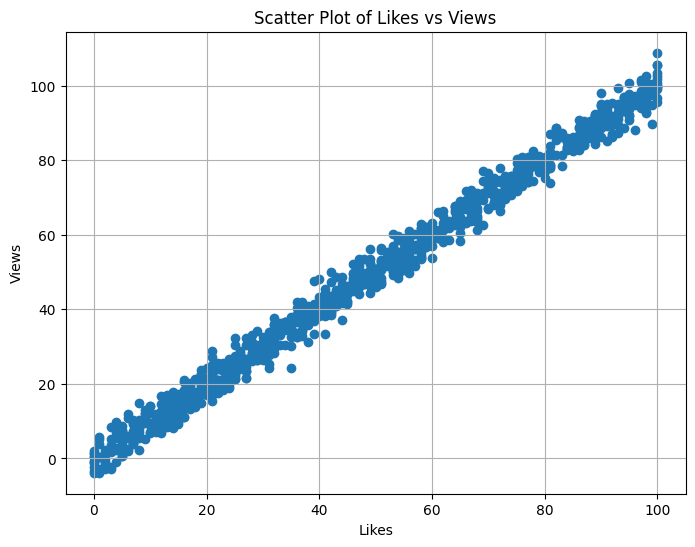

In [60]:
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Likes')
plt.ylabel('Views')
plt.title('Scatter Plot of Likes vs Views')
plt.grid(True)
plt.show()

For the x–y dataset, the points lie almost exactly along a straight line with positive slope, indicating an extremely strong linear relationship. This visual observation confirms the very high Pearson correlation coefficient (r=0.9951) computed previously, showing that the variables are nearly perfectly linearly dependent.

In [61]:
y = data1b['y'].tolist()
x = data1b['x'].tolist()

# min and max manually
min_y = min(y)
max_y = max(y)

min_x = min(x)
max_x = max(x)

# Normalized manually
y_normalized = []
for dep in y:
    norm_y = (dep - min_y) / (max_y - min_y)
    y_normalized.append(norm_y)

x_normalized = []
for ind in x:
    norm_x = (ind - min_x) / (max_x - min_x)
    x_normalized.append(norm_x)


# First 5 normalized pairs
for i in range(5):
    print("y:", y_normalized[i], "x:", x_normalized[i])

y: 0.22526016142660465 x: 0.24
y: 0.45518335676191574 x: 0.5
y: 0.1868364708545097 x: 0.15
y: 0.3586709740437467 x: 0.38
y: 0.8085145227193867 x: 0.87


In [62]:
import random

# Normalized data
x = x_normalized
y = y_normalized

# User-defined percentages
train_percentage = 80
test_percentage = 20

if train_percentage + test_percentage != 100:
    print("Error: percentages must add up to 100.")
else:
    # Creates pairs so x and y stay matched
    data = []
    for i in range(len(x)):
        data.append([x[i], y[i]])

    # Shuffles randomly
    random.shuffle(data)

    # Splits point
    train_size = int(len(data) * train_percentage / 100)

    # Creates subsets
    train_set = data[:train_size]
    test_set = data[train_size:]

    # Separates again into x and y
    x_train = []
    y_train = []
    for pair in train_set:
        x_train.append(pair[0])
        y_train.append(pair[1])

    x_test = []
    y_test = []
    for pair in test_set:
        x_test.append(pair[0])
        y_test.append(pair[1])

    # Prints sizes
    print("Total samples:", len(data))
    print("Training samples:", len(train_set))
    print("Test samples:", len(test_set))

    # Shows first 5 examples
    print("\nFirst 5 training samples:")
    for i in range(min(5, len(train_set))):
        print(train_set[i])

    print("\nFirst 5 test samples:")
    for i in range(min(5, len(test_set))):
        print(test_set[i])

Total samples: 999
Training samples: 799
Test samples: 200

First 5 training samples:
[0.13, 0.12532631630363922]
[0.62, 0.5564169151420245]
[0.49, 0.49796283185420526]
[0.27, 0.22671832110888876]
[0.18, 0.17473028252055303]

First 5 test samples:
[0.42, 0.37531290637060855]
[0.29, 0.2972838748844364]
[0.89, 0.8246185321500072]
[0.13, 0.12052127241475001]
[0.95, 0.8742923744946357]


The dataset was randomly shuffled and then split into a training set and a test set according to the selected percentages. Each sample was kept as a pair [x,y] so that the independent and dependent variable remained correctly matched.

The percentage of data assigned to each subset was defined by assinging two new variables with: train_percentage = 80 and test_percentage = 20, meaning that 80% of the observations were used for training and 20% for testing. After the split, the training set contained 799 samples and the test set contained 200 samples, preserving the original data distribution.

In [63]:
learning_rate = 0.01
epochs = 100

# Initial parameter values
w = 0
b = 0

# To store loss per epoch
loss_history = []

# SGD training
for epoch in range(epochs):
    total_loss = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        y_i = y_train[i]

        # Prediction
        y_pred = w * x_i + b

        # Error
        error = y_pred - y_i

        # Loss for this sample
        sample_loss = error ** 2
        total_loss += sample_loss

        # Gradients of squared error
        dw = 2 * error * x_i
        db = 2 * error

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

    # Mean loss of epoch
    mean_loss = total_loss / len(x_train)
    loss_history.append(mean_loss)

    print("Epoch:", epoch + 1, "Loss:", mean_loss, "w:", w, "b:", b)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Epoch: 1 Loss: 0.022982957494137878 w: 0.6333176963726695 b: 0.16042347225632145
Epoch: 2 Loss: 0.002873587854243306 w: 0.7960041530462098 b: 0.07791942207463018
Epoch: 3 Loss: 0.0009327686950969167 w: 0.8543521613217059 b: 0.048329085363132775
Epoch: 4 Loss: 0.0006848293308846379 w: 0.8752788576377845 b: 0.03771641822069551
Epoch: 5 Loss: 0.0006535504727534345 w: 0.8827842829581769 b: 0.03391015183804892
Epoch: 6 Loss: 0.0006497472560039947 w: 0.8854761273080521 b: 0.03254502245245519
Epoch: 7 Loss: 0.000649337032854887 w: 0.886441565733542 b: 0.03205541451331875
Epoch: 8 Loss: 0.0006493125959118398 w: 0.8867878232552505 b: 0.031879815089121515
Epoch: 9 Loss: 0.0006493196135074868 w: 0.8869120096022763 b: 0.03181683580444546
Epoch: 10 Loss: 0.0006493241604592684 w: 0.8869565494254443 b: 0.03179424808631136
Epoch: 11 Loss: 0.000649326052369792 w: 0.8869725237728294 b: 0.03178614693030213
Epoch: 12 Loss: 0.0006493267644993903 w: 0.8869782530226604 b: 0.031783241425270906
Epoch: 13 Loss:

In [64]:
y_pred_test = []

for i in range(len(x_test)):
    prediction = w * x_test[i] + b
    y_pred_test.append(prediction)

# Mean Squared Error manually
mse = 0

for i in range(len(y_test)):
    mse += (y_test[i] - y_pred_test[i]) ** 2

mse = mse / len(y_test)

print("Mean Squared Error on test set =", mse)

Mean Squared Error on test set = 0.0007334751377880119


*Assume that the test set is 20% of the original dataset. What do you observe happens in the case where the data are not normalized?*

In [65]:
# Independent variable
x = data1b['x'].tolist()

# Dependent variable
y = data1b['y'].tolist()

# User defines percentages
train_percentage = 80
test_percentage = 20

if train_percentage + test_percentage != 100:
    print("Error: percentages must add up to 100.")
else:
    # Creates pairs so x and y stay matched
    data = []
    for i in range(len(x)):
        data.append([x[i], y[i]])

    # Shuffles randomly
    random.shuffle(data)

    # Splits point
    train_size = int(len(data) * train_percentage / 100)

    # Creates subsets
    train_set = data[:train_size]
    test_set = data[train_size:]

    # Separates again into x and y
    x_train = []
    y_train = []
    for pair in train_set:
        x_train.append(pair[0])
        y_train.append(pair[1])

    x_test = []
    y_test = []
    for pair in test_set:
        x_test.append(pair[0])
        y_test.append(pair[1])

    # Prints sizes
    print("Total samples:", len(data))
    print("Training samples:", len(train_set))
    print("Test samples:", len(test_set))

    # Shows first 5 examples
    print("\nFirst 5 training samples:")
    for i in range(min(5, len(train_set))):
        print(train_set[i])

    print("\nFirst 5 test samples:")
    for i in range(min(5, len(test_set))):
        print(test_set[i])

Total samples: 999
Training samples: 799
Test samples: 200

First 5 training samples:
[95, 94.08853397]
[51, 51.90142035]
[34, 36.72396986]
[90, 89.91004752]
[56, 59.16236621]

First 5 test samples:
[61, 66.16652565]
[0, -1.040114209]
[2, -0.121860502]
[62, 61.26514581]
[92, 95.3958003]


In [66]:
learning_rate = 1e-12
epochs = 20

# Initial parameter values
w = 0
b = 0

# To store loss per epoch
loss_history = []

# SGD training
for epoch in range(epochs):
    total_loss = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        y_i = y_train[i]

        # Prediction
        y_pred = w * x_i + b

        # Error
        error = y_pred - y_i

        # Loss for this sample
        sample_loss = error ** 2
        total_loss += sample_loss

        # Gradients of squared error
        dw = 2 * error * x_i
        db = 2 * error

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

    # Mean loss of epoch
    mean_loss = total_loss / len(x_train)
    loss_history.append(mean_loss)

    print("Epoch:", epoch + 1, "Loss:", mean_loss, "w:", w, "b:", b)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Epoch: 1 Loss: 3438.409217219336 w: 5.476684020445605e-06 b: 8.12459191205447e-08
Epoch: 2 Loss: 3438.3716696538295 w: 1.0953338065349152e-05 b: 1.6249139351525445e-07
Epoch: 3 Loss: 3438.334122499333 w: 1.6429962134874706e-05 b: 2.4373642318656396e-07
Epoch: 4 Loss: 3438.296575755851 w: 2.1906556229186364e-05 b: 3.249810081369062e-07
Epoch: 5 Loss: 3438.2590294233896 w: 2.738312034844814e-05 b: 4.0622514836871565e-07
Epoch: 6 Loss: 3438.221483501926 w: 3.2859654492824254e-05 b: 4.874688438844272e-07
Epoch: 7 Loss: 3438.1839379914595 w: 3.833615866247846e-05 b: 5.687120946864736e-07
Epoch: 8 Loss: 3438.146392891982 w: 4.381263285757508e-05 b: 6.499549007772888e-07
Epoch: 9 Loss: 3438.108848203499 w: 4.928907707827806e-05 b: 7.311972621593096e-07
Epoch: 10 Loss: 3438.0713039260013 w: 5.476549132475152e-05 b: 8.124391788349687e-07
Epoch: 11 Loss: 3438.0337600594903 w: 6.024187559715947e-05 b: 8.936806508066976e-07
Epoch: 12 Loss: 3437.996216603951 w: 6.571822989566584e-05 b: 9.7492167807

In [67]:
mse_test = 0

for i in range(len(x_test)):
    y_pred = w * x_test[i] + b
    mse_test += (y_test[i] - y_pred) ** 2

mse_test = mse_test / len(x_test)

print("\nMean Squared Error on test set =", mse_test)


Mean Squared Error on test set = 3132.971865018759


This experiment shows exactly why feature scaling is so important for SGD. Without normalization, the algorithm's gradients become massive and erratic. To stop the calculations from exploding and crashing the model, we had to shrink the learning rate to a microscopic 1e-12. Even with this tiny rate, the model learns too slowly and finishes with a huge Mean Squared Error. In short, without normalized data, SGD is highly unstable and practically unusable.

In [68]:
# Normalized data
x = x_normalized
y = y_normalized

In [70]:
random.seed(42)   # fixed seed so all experiments use the same split

data = []
for i in range(len(x_normalized)):
    data.append([x_normalized[i], y_normalized[i]])

random.shuffle(data)

train_size = int(len(data) * 0.80)

train_set = data[:train_size]
test_set = data[train_size:]

x_train = []
y_train = []
for pair in train_set:
    x_train.append(pair[0])
    y_train.append(pair[1])

x_test = []
y_test = []
for pair in test_set:
    x_test.append(pair[0])
    y_test.append(pair[1])

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

Training samples: 799
Test samples: 200


In [71]:
def train_sgd(x_train, y_train, learning_rate, epochs):
    w = 0
    b = 0

    for epoch in range(epochs):
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            # prediction
            y_pred = w * x_i + b

            # error
            error = y_pred - y_i

            # gradients
            dw = 2 * error * x_i
            db = 2 * error

            # update
            w = w - learning_rate * dw
            b = b - learning_rate * db

    return w, b

In [72]:
def compute_mse(x_test, y_test, w, b):
    mse = 0

    for i in range(len(x_test)):
        y_pred = w * x_test[i] + b
        mse += (y_test[i] - y_pred) ** 2

    mse = mse / len(x_test)
    return mse

In [73]:
learning_rates = [0.001, 0.01, 0.05]
epoch_values = [10, 50, 100]

results = []

for lr in learning_rates:
    for ep in epoch_values:
        w, b = train_sgd(x_train, y_train, lr, ep)
        mse = compute_mse(x_test, y_test, w, b)

        results.append([lr, ep, w, b, mse])


In [74]:
print("\nResults:")
for row in results:
    print(f"Learning rate = {row[0]}, Epochs = {row[1]}, w = {row[2]:.6f}, b = {row[3]:.6f}, Test MSE = {row[4]:.6f}")


Results:
Learning rate = 0.001, Epochs = 10, w = 0.652985, b = 0.162020, Test MSE = 0.005579
Learning rate = 0.001, Epochs = 50, w = 0.887321, b = 0.034428, Test MSE = 0.000663
Learning rate = 0.001, Epochs = 100, w = 0.890992, b = 0.032430, Test MSE = 0.000661
Learning rate = 0.01, Epochs = 10, w = 0.891246, b = 0.034434, Test MSE = 0.000667
Learning rate = 0.01, Epochs = 50, w = 0.891265, b = 0.034424, Test MSE = 0.000667
Learning rate = 0.01, Epochs = 100, w = 0.891265, b = 0.034424, Test MSE = 0.000667
Learning rate = 0.05, Epochs = 10, w = 0.892048, b = 0.038027, Test MSE = 0.000703
Learning rate = 0.05, Epochs = 50, w = 0.892048, b = 0.038027, Test MSE = 0.000703
Learning rate = 0.05, Epochs = 100, w = 0.892048, b = 0.038027, Test MSE = 0.000703


The experiment clearly demonstrates how the learning rate and the number of epochs interact to drive the Stochastic Gradient Descent algorithm toward optimal parameters. At a small learning rate (0.001), the algorithm takes relatively small steps down the error gradient, so the Mean Squared Error (MSE) improves gradually, dropping from 0.005579 at 10 epochs to 0.000661 at 100 epochs. Increasing the learning rate to 0.01 shows a much faster descent at first, since the MSE already reaches 0.000667 by epoch 10, but then stays exactly at 0.000667 at epochs 50 and 100. However, the most important takeaway comes from comparing all three learning rates. At 0.05, the MSE quickly reaches 0.000703 by epoch 10, but notably stays exactly at 0.000703 at epochs 50 and 100, which indicates that the model has converged early but to a slightly worse solution than the other cases. This plateau indicates that the model has fully "converged" for those settings, and running more epochs beyond this point yields no further improvement and simply wastes computational resources. Therefore, the optimal hyperparameter combination from this test is a learning rate of 0.001 run for 100 epochs, as it achieves the lowest error overall.